# <span style = "color:coral"> Customer Behaviour Classification </span>

***

In this project, we will try to predict if the customer purchase the product or not using various machine learning models and Deploy the model with Tkinter library

## Contents

The data represents details about 400 clients of a company including the unique ID, the gender, the age of the customer and the salary. Besides this, we have collected information regarding the buying decision - weather the customer decided to buy specific products or not.

## Let's Begin

### Import all necessary libraries

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

### Read 'Customer_Behaviour.csv' dataset and store it in a dataframe variable

In [2]:
df=pd.read_csv('Customer_Behaviour.csv')
df

,User ID,Gender,Age,EstimatedSalary,Purchased
0,15624510,Male,19,19000,0
1,15810944,Male,35,20000,0
2,15668575,Female,26,43000,0
3,15603246,Female,27,57000,0
4,15804002,Male,19,76000,0
...,...,...,...,...,...
395,15691863,Female,46,41000,1
396,15706071,Male,51,23000,1
397,15654296,Female,50,20000,1
398,15755018,Male,36,33000,0


### View the top 5 rows

In [3]:
df.head(5)

,User ID,Gender,Age,EstimatedSalary,Purchased
0,15624510,Male,19,19000,0
1,15810944,Male,35,20000,0
2,15668575,Female,26,43000,0
3,15603246,Female,27,57000,0
4,15804002,Male,19,76000,0


### View info of the dataset

In [4]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 400 entries, 0 to 399
Data columns (total 5 columns):
 #   Column           Non-Null Count  Dtype 
---  ------           --------------  ----- 
 0   User ID          400 non-null    int64 
 1   Gender           400 non-null    object
 2   Age              400 non-null    int64 
 3   EstimatedSalary  400 non-null    int64 
 4   Purchased        400 non-null    int64 
dtypes: int64(4), object(1)
memory usage: 15.8+ KB


### View basic statistical information about the dataset

In [5]:
df.describe()

,User ID,Age,EstimatedSalary,Purchased
count,4.000000e+02,400.000000,400.000000,400.000000
mean,1.569154e+07,37.655000,69742.500000,0.357500
std,7.165832e+04,10.482877,34096.960282,0.479864
min,1.556669e+07,18.000000,15000.000000,0.000000
25%,1.562676e+07,29.750000,43000.000000,0.000000
50%,1.569434e+07,37.000000,70000.000000,0.000000
75%,1.575036e+07,46.000000,88000.000000,1.000000
max,1.581524e+07,60.000000,150000.000000,1.000000


### Check for any null values

In [6]:
df.isna().sum()

User ID            0
Gender             0
Age                0
EstimatedSalary    0
Purchased          0
dtype: int64

### View unique values in Gender

In [7]:
df['Gender'].unique()

array(['Male', 'Female'], dtype=object)

### Convert male to 0 and Female to 1 in Gender column

In [8]:
df['Gender'] = df['Gender'].map({'Male': 0, 'Female': 1})

In [9]:
df.head(5)

,User ID,Gender,Age,EstimatedSalary,Purchased
0,15624510,0,19,19000,0
1,15810944,0,35,20000,0
2,15668575,1,26,43000,0
3,15603246,1,27,57000,0
4,15804002,0,19,76000,0


#### Drop user ID column

In [10]:
df.drop(columns=['User ID'],inplace=True)


In [11]:
df.head()

,Gender,Age,EstimatedSalary,Purchased
0,0,19,19000,0
1,0,35,20000,0
2,1,26,43000,0
3,1,27,57000,0
4,0,19,76000,0


## <span style = "color: orange"> Data Visualization </span>

### Plot heatmap to view the correlation between features

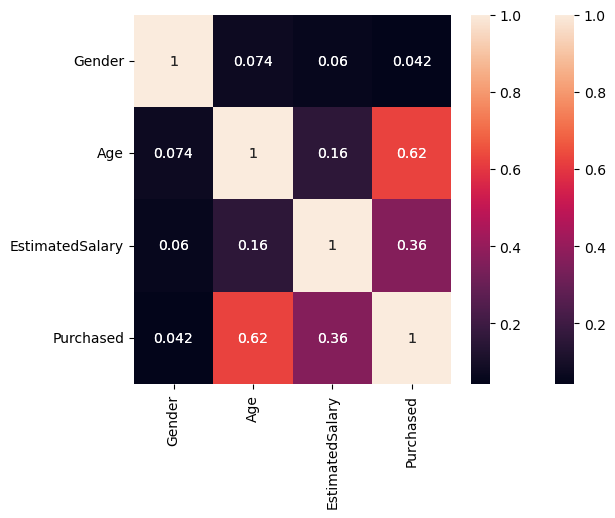

In [70]:
sns.heatmap(df.corr(),annot = True)
plt.show()

### Plot a countplot of gender with respect to purchased

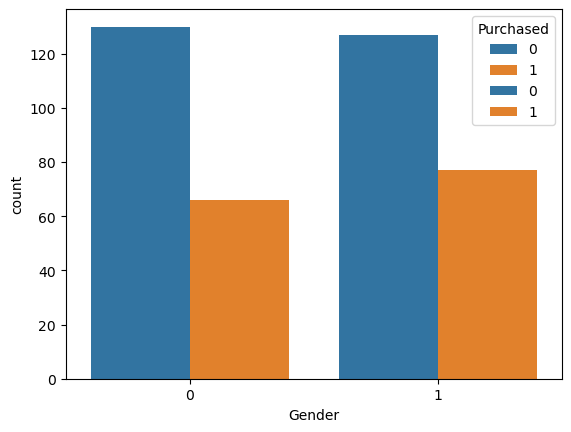

In [67]:
sns.countplot(x='Gender',hue='Purchased',data=df)
plt.show()

### Plot a displot of Age

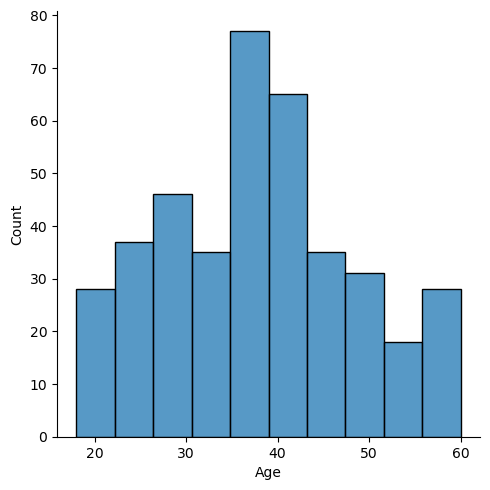

In [60]:
sns.displot(df['Age'])

### Plot pairplot of the dataset

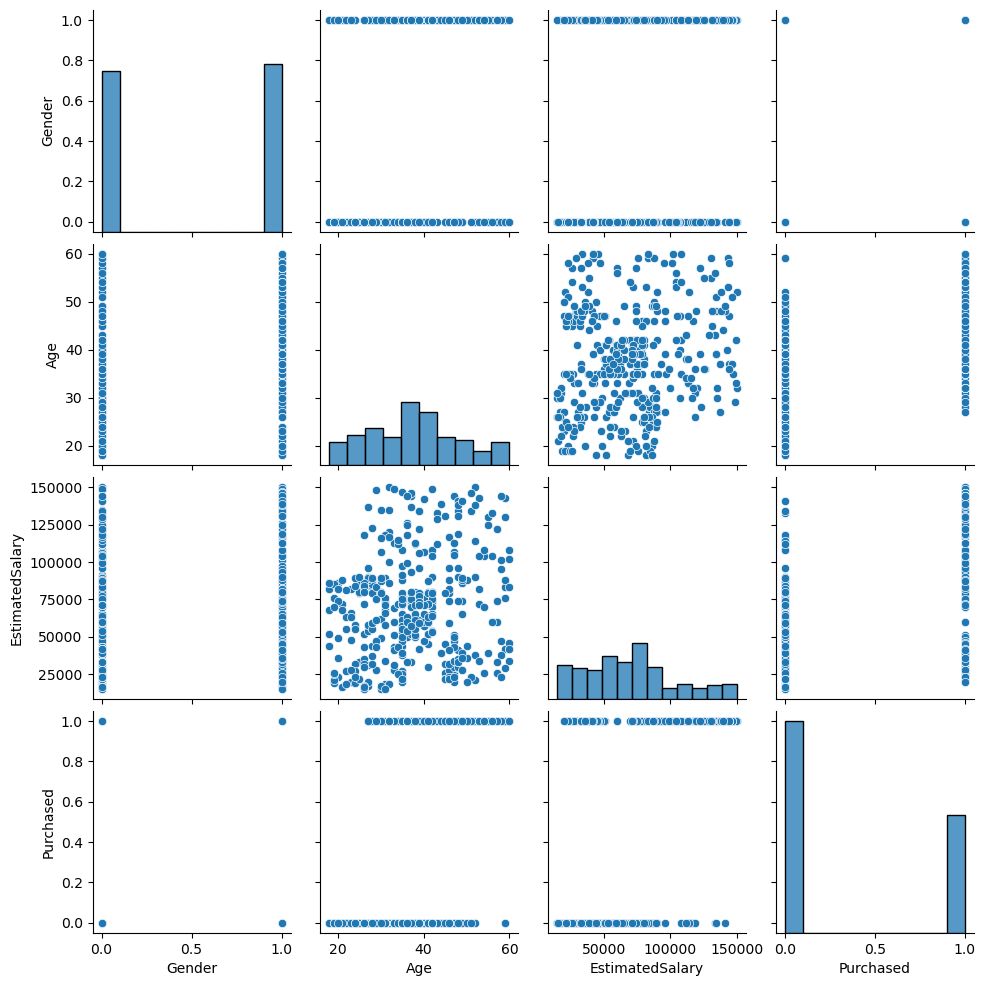

In [71]:
sns.pairplot(df)
plt.show()

## Data Preprocessing

### Split the dataset into input and target variables

In [12]:
X =  df.drop(columns = ['Purchased'])
y = df['Purchased']

### Scale the data using StandardScaler

In [13]:
from sklearn.preprocessing import StandardScaler

In [14]:
scaler = StandardScaler()

In [15]:
xcolumns = X.columns

In [16]:
X = scaler.fit_transform(X)

In [17]:
X = pd.DataFrame(X, columns = xcolumns)

In [18]:
X.head()

,Gender,Age,EstimatedSalary
0,-1.020204,-1.781797,-1.490046
1,-1.020204,-0.253587,-1.460681
2,0.980196,-1.113206,-0.785290
3,0.980196,-1.017692,-0.374182
4,-1.020204,-1.781797,0.183751


### Split the dataset into training and testing set

In [19]:
from sklearn.model_selection import train_test_split

In [20]:
X_train, X_test,y_train,y_test=train_test_split(X,y, test_size = 0.25, random_state = 100)

### Check shape of X_train and X_test

In [21]:
X_train.shape

(300, 3)

In [22]:
X_test.shape

(100, 3)

## ML Models

### Logistic Regression Classifier

In [23]:
from sklearn.linear_model import LogisticRegression
from  sklearn import metrics
from sklearn.model_selection import cross_val_score

In [24]:
model1=LogisticRegression()

In [25]:
model1.fit(X_train,y_train)

LogisticRegression()

In [26]:
model1.score(X_train,y_train)

0.85

In [27]:
print('Score of our trained model is:',model1.score(X_train,y_train))

Score of our trained model is: 0.85


In [28]:
y_pred=model1.predict(X_test)
y_pred

array([0, 0, 0, 0, 0, 1, 0, 0, 0, 0, 0, 1, 0, 1, 1, 1, 0, 0, 0, 0, 0, 0,
       0, 0, 1, 0, 0, 1, 0, 0, 0, 1, 0, 1, 1, 1, 1, 0, 0, 0, 0, 0, 0, 1,
       1, 0, 1, 0, 0, 1, 0, 0, 0, 0, 1, 0, 1, 1, 1, 1, 0, 0, 0, 0, 0, 0,
       1, 0, 0, 1, 0, 1, 1, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0,
       0, 0, 0, 0, 1, 0, 1, 0, 1, 0, 0, 0], dtype=int64)

In [29]:
from sklearn import metrics
print("Accuracy score of our prediction is: ",metrics.accuracy_score(y_test,y_pred))

Accuracy score of our prediction is:  0.87


In [30]:
print('Confusion matrix',metrics.confusion_matrix(y_test,y_pred))
print('Classification Report is:')
print(metrics.classification_report(y_test,y_pred))

Confusion matrix [[62  3]
 [10 25]]
Classification Report is:
              precision    recall  f1-score   support

           0       0.86      0.95      0.91        65
           1       0.89      0.71      0.79        35

    accuracy                           0.87       100
   macro avg       0.88      0.83      0.85       100
weighted avg       0.87      0.87      0.87       100



In [31]:
scores=cross_val_score(model1,X,y,cv=5)
lr_cv=scores.mean()

In [32]:
print('Mean of cross validation score is: ',lr_cv)

Mean of cross validation score is:  0.82


### Random Forest Classifier

In [33]:
from sklearn.ensemble import RandomForestClassifier

In [34]:
model2 = RandomForestClassifier(n_estimators=20)

In [35]:
model2.fit(X_train,y_train)

RandomForestClassifier(n_estimators=20)

In [36]:
model2.score(X_train,y_train)

0.9966666666666667

In [37]:
print('Score of our trained model is:',model2.score(X_train,y_train))

Score of our trained model is: 0.9966666666666667


In [38]:
y_pred=model2.predict(X_test)
y_pred

array([0, 1, 0, 1, 0, 1, 0, 0, 0, 0, 0, 0, 0, 1, 1, 1, 0, 0, 0, 0, 0, 1,
       0, 0, 1, 0, 0, 1, 0, 0, 0, 1, 1, 0, 1, 1, 1, 0, 0, 0, 0, 0, 0, 1,
       1, 0, 1, 0, 0, 1, 0, 0, 0, 0, 1, 0, 1, 1, 0, 1, 0, 1, 0, 0, 0, 0,
       1, 0, 0, 1, 0, 1, 1, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0,
       0, 1, 0, 0, 1, 0, 1, 0, 1, 0, 0, 0], dtype=int64)

In [39]:
print("Accuracy score of our prediction is: ",metrics.accuracy_score(y_test,y_pred))

Accuracy score of our prediction is:  0.92


In [40]:
print('Confusion matrix',metrics.confusion_matrix(y_test,y_pred))


Confusion matrix [[63  2]
 [ 6 29]]


In [41]:
print('Classification Report is:')
print(metrics.classification_report(y_test,y_pred))

Classification Report is:
              precision    recall  f1-score   support

           0       0.91      0.97      0.94        65
           1       0.94      0.83      0.88        35

    accuracy                           0.92       100
   macro avg       0.92      0.90      0.91       100
weighted avg       0.92      0.92      0.92       100



In [42]:
scores=cross_val_score(model2,X,y,cv=5)
rf_cv=scores.mean()
print('Mean of cross validation score is: ',rf_cv)

Mean of cross validation score is:  0.85


### Support Vector Machine

In [43]:
from sklearn.svm import SVC

In [44]:
model=SVC()

In [45]:
model.fit(X_train,y_train)

SVC()

In [46]:
model.score(X_train,y_train)

0.9033333333333333

In [47]:
print('Score of our trained model is',model.score(X_train,y_train))

Score of our trained model is 0.9033333333333333


In [48]:
y_pred=model.predict(X_test)

In [49]:
metrics.accuracy_score(y_test, y_pred)

0.92

In [50]:
print('Accuracy score of our prediction is:',metrics.accuracy_score(y_test, y_pred))

Accuracy score of our prediction is: 0.92


In [51]:
metrics.confusion_matrix(y_test,y_pred)

array([[62,  3],
       [ 5, 30]], dtype=int64)

In [52]:
print('Classification report is:',metrics.classification_report(y_test,y_pred))

Classification report is:               precision    recall  f1-score   support

           0       0.93      0.95      0.94        65
           1       0.91      0.86      0.88        35

    accuracy                           0.92       100
   macro avg       0.92      0.91      0.91       100
weighted avg       0.92      0.92      0.92       100



In [53]:
scores=cross_val_score(model,X,y,cv=5)
svm_cv=scores.mean()

In [54]:
print('Mean of cross validation score is: ',svm_cv)

Mean of cross validation score is:  0.9


### Assign cross val scores of all models into a dataframe

In [55]:
cv_df=pd.DataFrame({
    'Model':['Logistic Regression','Random Forest','Support Vector Machine'],
    'Scores':[lr_cv,rf_cv,svm_cv]
})
cv_df

,Model,Scores
0,Logistic Regression,0.82
1,Random Forest,0.85
2,Support Vector Machine,0.90


***

## Deploy the model with highest score using Tkinter

In [56]:
### In this case its SVM Classifier
df.head()

,Gender,Age,EstimatedSalary,Purchased
0,0,19,19000,0
1,0,35,20000,0
2,1,26,43000,0
3,1,27,57000,0
4,0,19,76000,0


#### Import all modules from Tkinter

In [57]:
from tkinter import *

### Define a function that will output to an entry box in Tkinter

In [58]:
def getPrediction():
    # .get() function is used to fetch the value from the entrybox and radiobuttons
    age1 = int(age.get())
    salary1 = int(salary.get())
    gender1 = int(gender.get())
    print(gender1)
    
    resultbox.delete(0, END)
    
   
    
    result = model.predict(scaler.transform([[gender1,age1,salary1]]))
    print(result)
    
    if result[0] == 1:
        resultbox.insert(0, 'Purchased')
    
    else:
        resultbox.insert(0, 'Not Purchased')

### Create Tkinter window with all necessary entryboxes and labels

In [59]:
# Creating a tkinter object
window = Tk()

# Setting window size to 350 x 300
window.geometry("350x300")

# Set window title
window.title('Customer Purchase Perdiction')

label = Label(window , text = 'Enter the Details here:', font=('calibre',10, 'bold')).pack()

# A label displaying age and an entry box for the user to input the age
agelabel = Label(window, text = 'Age')
age = Entry(window)

# A label for salary and an entry box for the user to input the salary
salarylabel = Label(window, text = 'Estimated Salary')
salary = Entry(window)

# Set the datatype of gender variable as string
gender = StringVar()

# Set the default value of gender as 0
gender.set(0)

# Label displaying gender
genderlabel = Label(window, text = 'Gender')

# The pack() geometry manager organizes widgets in blocks before placing them in the parent widget
agelabel.pack()
age.pack()
salarylabel.pack()
salary.pack()
genderlabel.pack()

# Create Radiobuttons for fetching the gender
Radiobutton(window, text='Male', variable=gender, value=0).pack()
Radiobutton(window, text='Female', variable=gender, value=1).pack()

# Button with the command of the function we made to get the predicton using our trained model
button = Button(window, text = 'Get Prediction', command = getPrediction).pack()

# Create an entry box to display our predicted value
resultbox = Entry(window)
resultbox.pack()

window.mainloop()

0
[0]


C:\Users\HP\anaconda3\lib\site-packages\sklearn\base.py:450: UserWarning: X does not have valid feature names, but StandardScaler was fitted with feature names
  warnings.warn(
C:\Users\HP\anaconda3\lib\site-packages\sklearn\base.py:450: UserWarning: X does not have valid feature names, but SVC was fitted with feature names
  warnings.warn(


1
[1]


C:\Users\HP\anaconda3\lib\site-packages\sklearn\base.py:450: UserWarning: X does not have valid feature names, but StandardScaler was fitted with feature names
  warnings.warn(
C:\Users\HP\anaconda3\lib\site-packages\sklearn\base.py:450: UserWarning: X does not have valid feature names, but SVC was fitted with feature names
  warnings.warn(


***

# <span style = "color:green;font-size:40px"> Great Job! </span>